In [26]:
import json
import nibabel as nib

In [2]:
import pandas as pd

In [4]:
d ={}
with open('/common/ganesanv/tlab/runs/ssl_finetuning/adni_vitb16_fixed/adni_patient_splits.json', 'r') as f:
    d = json.load(f)


In [9]:
d['splits'].keys()

dict_keys(['test', 'train', 'val'])

In [10]:
test_patients = d['splits']['test']
val_patients = d['splits']['val']
train_patients = d['splits']['train']






In [15]:
from pathlib import Path
base_path = Path('/common/ganesanv/tlab/data/ADNI')

In [47]:
import pandas as pd

labels_df = pd.read_csv('/common/ganesanv/tlab/data/ADNI/ADNI1_Complete_3Yr_1.5T_7_21_2026.csv')


In [75]:
test_img_paths = []
test_img_labels = []
for patient in test_patients:
    dir = base_path / patient
    img_paths = list(dir.rglob("*.nii"))
    test_img_paths.extend(img_paths)

    label = labels_df.loc[labels_df['Subject'] == patient, 'Group'].iloc[0]
    n_imgs = len(list(img_paths))
    labels_list = [label] * n_imgs
    
    test_img_labels.extend(labels_list)


In [76]:
test_img_labels

['MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'AD',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'AD',
 'AD',
 'AD',
 'AD',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'CN',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'MCI',
 'CN',
 'CN',
 'CN',
 'CN',
 

In [81]:

mask= np.where(np.array(test_img_labels) != 'MCI')
test_img_paths_subset = np.array(test_img_paths)[mask]
test_img_labels_subset = np.array(test_img_labels)[mask]

/home/ganesanv/.conda/envs/dinov3/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/ganesanv/.conda/envs/dinov3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


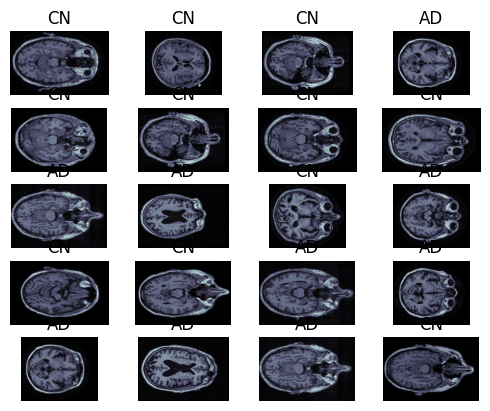

In [97]:
import numpy as np
import math
import matplotlib.pyplot as plt

n_visuals = 20
max_cols = 4
slice_frac = 0.5
cols = min(n_visuals, max_cols)
rows = math.ceil(n_visuals / cols)

fig, ax = plt.subplots(rows, cols, tight_layout=True, gridspec_kw={'wspace':0, 'hspace':0.2})
for idx in range(n_visuals):
    i = np.random.randint(0, len(test_img_paths_subset)-1)
    img = nib.load(test_img_paths_subset[i])
    img = nib.as_closest_canonical(img).get_fdata()
    n_slices = img.shape[-1]

    slice_img = img[:, :, round(slice_frac * n_slices)]

    row_idx = idx // cols
    col_idx = idx % cols

    ax[row_idx, col_idx].imshow(slice_img, cmap=plt.cm.bone)
    ax[row_idx, col_idx].axis('off')
    ax[row_idx, col_idx].set_title(test_img_labels_subset[i])




In [91]:
val_img_paths = []
val_img_labels = []
for patient in val_patients:
    dir = base_path / patient
    img_paths = list(dir.rglob("*.nii"))
    val_img_paths.extend(img_paths)

    label = labels_df.loc[labels_df['Subject'] == patient, 'Group'].iloc[0]
    n_imgs = len(list(img_paths))
    labels_list = [label] * n_imgs
    
    val_img_labels.extend(labels_list)


mask_val= np.where(np.array(val_img_labels) != 'MCI')
val_img_paths_subset = np.array(val_img_paths)[mask_val]
val_img_labels_subset = np.array(val_img_labels)[mask_val]


In [87]:
val_img_paths = [str(p) for p in val_img_paths]
test_img_paths = [str(k) for k in test_img_paths]
print(np.intersect1d(np.array(val_img_paths) ,np.array(test_img_paths)))

[]


In [95]:
unique_val, val_counts = np.unique(val_img_labels_subset, return_counts=True)
unique_test, test_counts = np.unique(test_img_labels_subset, return_counts=True)

print("Val props", unique_val, (val_counts / val_counts.sum()))
print("Test props", unique_test, (test_counts / test_counts.sum()))

Val props ['AD' 'CN'] [0.38235294 0.61764706]
Test props ['AD' 'CN'] [0.39779006 0.60220994]


/home/ganesanv/.conda/envs/dinov3/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/ganesanv/.conda/envs/dinov3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


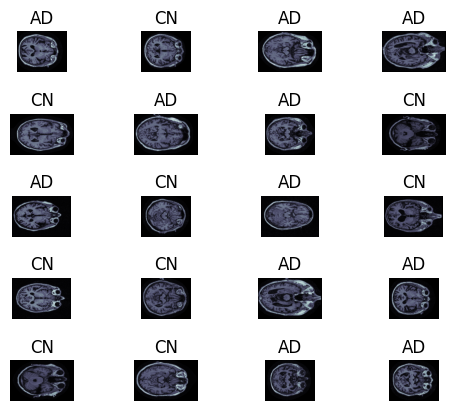

In [96]:
import numpy as np
import math
import matplotlib.pyplot as plt

n_visuals = 20
max_cols = 4
slice_frac = 0.5
cols = min(n_visuals, max_cols)
rows = math.ceil(n_visuals / cols)

fig, ax = plt.subplots(rows, cols, tight_layout=True, gridspec_kw={'wspace':0, 'hspace':1})
for idx in range(n_visuals):
    i = np.random.randint(0, len(val_img_paths_subset)-1)
    img = nib.load(val_img_paths_subset[i])
    img = nib.as_closest_canonical(img).get_fdata()
    n_slices = img.shape[-1]

    slice_img = img[:, :, round(slice_frac * n_slices)]

    row_idx = idx // cols
    col_idx = idx % cols

    ax[row_idx, col_idx].imshow(slice_img, cmap=plt.cm.bone)
    ax[row_idx, col_idx].axis('off')
    ax[row_idx, col_idx].set_title(val_img_labels_subset[i])




In [98]:
train_img_paths = []
train_img_labels = []
for patient in train_patients:
    dir = base_path / patient
    img_paths = list(dir.rglob("*.nii"))
    train_img_paths.extend(img_paths)

    label = labels_df.loc[labels_df['Subject'] == patient, 'Group'].iloc[0]
    n_imgs = len(list(img_paths))
    labels_list = [label] * n_imgs
    
    train_img_labels.extend(labels_list)


In [ ]:
train_n_slices = []

for p in train_img_paths:
    im = nib.load(p)
    train_n_slices.append(im.shape[-1])

np.min(train_n_slices)

np.int64(146)

Bad pipe message: %s [b'am\r\nContent-Type: application/json\r\nContent-Length: 212\r\n\r\n{"jsonrpc":"2.0","id":1,"method":"initialize","params"', b'"protocolVersion":"2025-06-18","capabilities":{"tools":{}', b'resources":{},"prompts":{},"roots":{}},"cli']
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ganesanv/.conda/envs/dinov3/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/ganesanv/.conda/envs/dinov3/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/home/ganesanv/.conda/envs/dinov3/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
  File "/home/ganesanv/.conda/envs/dinov3/lib/python3.10/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg